# CRVSE POS Only Hyperparameter Optuna Tunning - CRVSENet 1d (Round 1)

## 1. Imports & Configs

In [1]:
import h5py, torch, os, time, optuna
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from dataclasses import dataclass
from scipy import stats
from torch.utils.data import Dataset, DataLoader
from scipy.signal import resample
from collections import defaultdict
from tqdm import tqdm
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

# Fixed config - never tuned

H5_PATHS = {
    "ubfc_phys"  : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ubfc_phys.h5",
    "ubfc_rppg"  : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ubfc_rppg.h5",
    "ecg_fitness": "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ecg_fitness.h5",
    "mcd_rppg"   : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/mcd_rppg.h5",
}

MODEL_NAME = "CRVSENET_BASE"
HR_MIN = 40.0
HR_MAX = 180.0 
MAX_NAN_FRAC = 0.10 
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tuning config
N_TRIALS = 50
N_EPOCHS = 50
BATCH_SIZE = 32
PRUNER_WARMUP = 5

print(f"Device: {DEVICE}")
print(f"Trials : {N_TRIALS} | Max epochs/trials {N_EPOCHS}")

Device: cuda
Trials : 50 | Max epochs/trials 50


## 2. Window extractor fuction

In [ ]:
def extract_windows(rppg: np.ndarray, hr_cont: np.ndarray, fps: float, window_sec: int, stride_sec: int, target_frames: int, 
                    max_nan_frac: float, hr_min: float, hr_max: float) -> tuple:
    """
    Extract sliding windows from one recording.

    Returns:
        windows : list of np.ndarray, each shape (target_frames,)
        labels : list of float, HR in BPM
    """
    window_frames = int(fps * window_sec)
    stride_frames = int(fps * stride_sec)
    n_frames = len(rppg)

    windows : list[np.ndarray] = []
    labels : list[float] = []

    for start in range(0, n_frames - window_frames + 1, stride_frames):
        end = start + window_frames

        rppg_win = rppg[start:end]
        hr_win = hr_cont[start:end]

        # NaN check on label
        nan_frac = np.sum(np.isnan(hr_win)) / len(hr_win)
        if nan_frac > max_nan_frac:
            continue
        
        # Compute scalar HR label
        hr_label = float(np.nanmean(hr_win))

        # Physiological sanity check
        if not (hr_min <= hr_label <= hr_max):
            continue

        # NaN check on signal
        if np.any(np.isnan(rppg_win)):
            continue

        # Resample to fixed length
        if len(rppg_win) != target_frames:
            rppg_win = resample(rppg_win, target_frames).astype(np.float32)

        # Z-score normalisation per window
        std = rppg_win.std()
        if std < 1e-6:
            continue
        rppg_win = (rppg_win - rppg_win.mean()) / std

        windows.append(rppg_win.astype(np.float32))
        labels.append(hr_label)

    return windows, labels

## 3. Index builder

Reads all HDF5 files, builds a flat list of `(dataset_name, subject_id, session_id)` tuples, and calls the extractor. Keeps subject identity for split purposes.

In [3]:
def build_index(h5_paths : dict[str, str], window_sec: int, stride_sec: int, target_frames: int, max_nan_frac: float, hr_min: float, hr_max: float) -> tuple[list[dict], list[str]]:
    """
    Returns: 
        samples : list of dicts with keys: signal, hr_label, subject_key, dataset
        subject_keys : sorted list of unique subject identifiers (dataset + subject_id)
    """
    samples : list[dict] = []
    subject_keys : set[str] = set()

    for dataset_name, path in h5_paths.items():
        with h5py.File(path, "r") as file:
            subjects = file["subjects"]

            for subj_id in subjects.keys():
                subj_key = f"{dataset_name}__{subj_id}"
                subject_keys.add(subj_key)
                recordings = subjects[subj_id]["recordings"]

                for sess_id in recordings.keys():
                    rec = recordings[sess_id]
                    fps = float(rec.attrs["fps"])
                    rppg = rec["rppg_signal"][:]
                    hr = rec["hr_continuous"][:]

                    wins, labels = extract_windows(rppg, hr, fps, window_sec,
                                                stride_sec, target_frames,
                                                max_nan_frac, hr_min, hr_max)

                    for win, label in zip(wins, labels):
                        samples.append({
                            "signal" : win,
                            "hr_label" : label,
                            "subject_key" : subj_key,
                            "dataset" : dataset_name
                        })

    print(f"Total windows extracted : {len(samples)}")
    print(f"Total unique subjects : {len(subject_keys)}")
    return samples, sorted(subject_keys)

## 4. Subject-level train/val/test split

In [4]:
def subject_split(subject_keys: list[str], train_frac: float = 0.70,  val_frac: float = 0.15,seed : int = 42) -> tuple[set[str], set[str], set[str]]:
    """
    Returns three sets of subject_key strings.
    test_frac = 1 - train_frac - val_frac.
    """
    rng = np.random.default_rng(seed)
    keys = np.array(subject_keys)
    rng.shuffle(keys)

    n = len(keys)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_keys : set[str] = set(keys[:n_train])
    val_keys : set[str] = set(keys[n_train : n_train + n_val])
    test_keys : set[str] = set(keys[n_train + n_val :])

    print(f"Train subjects : {len(train_keys)}")
    print(f"Val subjects : {len(val_keys)}")
    print(f"Test subjects : {len(test_keys)}")
    return train_keys, val_keys, test_keys

## 5. Dataset class

In [5]:
class CRVSEDataset(Dataset):
    """
    PyTorch Dataset for CRVSE Phase 2 rPPG -> HR estimation.
    
    Args: 
        samples : list of dicts from build_index()
        subject_set : set of subject_key strings to include (train/val/test)
    """
    def __init__(self, samples: list[dict], subject_set: set[str]) -> None:
        self.items: list[dict] = [sample for sample in samples if sample["subject_key"] in subject_set]
        print(f"Dataset size: {len(self.items)} windows")

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        item = self.items[idx]
        signal = torch.tensor(item["signal"], dtype=torch.float32).unsqueeze(0)
        # shape: (1, TARGET_Framse) - (channels, time)
        label = torch.tensor(item["hr_label"], dtype=torch.float32)
        return signal, label 

## 6. Model architecture

In [ ]:
# TCN block
class TCNBlock(nn.Module):
    """
    One dilated causal TCN block with residual connection.
    
    Casual padding ensures no future information leaks into the current
    timestep.
    
    Args:
        in_channels : number of input channels
        out_channels : number of output channels
        kernel_size : convolution kernel size
        dilation : dilation factor (doubles each block)
        dropout : dropout probability
    """
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, dilation: int = 1, dropout : float = 0.2) -> None:
        super().__init__()
        # Casual padding - pad only on the left so output at time t depends only on inputs at time ≤ t

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size,
                              dilation=dilation, padding=0)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size,
                              dilation=dilation, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

         # 1x1 conv to match channels for residual if needed
        self.residual_proj = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

        self._kernel_size = kernel_size
        self._dilation = dilation

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        # x: (B, C, T)
        residual = self.residual_proj(x)
        causal_pad = (self._kernel_size - 1) * self._dilation
    

        out = F.pad(x, (causal_pad, 0)) # left-pad only
        out = self.conv1(out)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.dropout(out)

        out = F.pad(out, (causal_pad, 0))
        out = self.conv2(out)
        out = self.bn2(out)
        out = F.relu(out)
        out = self.dropout(out)

        return F.relu(out + residual)


class CRVSENet(nn.Module):
    """
    1D CNN + TCN baseline for rPPG -> HR estimation.
    
    Architecture:
        Input (1, 240)
            ↓
        Conv Encoder - 3x [Conv1d -> BN -> ReLU -> Dropout]
            ↓
        TCN Stack - 4 x TCNBlock with exponential dilation
            ↓
        Global Average Pooling -> (channels,)
            ↓
        Regression Head - FC -> ReLU -> FC -> scalar BPM
    
    Args:
        in_channels : input channels (1 for POS-only, 3 for ensemble)
        base_channels : feature width of the conv encoder
        tcn_channels : feature width of the TCN stack
        tcn_layers : number of TCN blocks
        tcn_kernel : TCN kernel size
        dropout : dropout probability throughout
        hr_min / hr_max : output clamped too physiological range
    """
    def __init__(self, in_channels: int = 1, base_channels: int = 32, tcn_channels: int = 64,
                tcn_layers: int = 4, tcn_kernel:int = 3, dropout: float = 0.2, 
                 hr_min: float = 40.0, hr_max: float = 180.0,) -> None:
        super().__init__()
        self.hr_min = hr_min
        self.hr_max = hr_max

        # Conv Encoder
        # Extracts local pulse wave features:
        # peak morphology, amplitude, inter-peak shape
        self.encoder = nn.Sequential(
            # Block 1 - broad receptive field, low-level features
            nn.Conv1d(in_channels, base_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Block 2 - medium receptive field
            nn.Conv1d(base_channels, base_channels * 2, kernel_size=5, padding=2),
            nn.BatchNorm1d(base_channels * 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Block 3 - narrow receptive field, detailed features
            nn.Conv1d(base_channels * 2, tcn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(tcn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # TCN Stack
        # Expotential dilation: 1, 2, 4, 8
        # at 30fps, dilation=8 + kernel-3 covers ~0.7s context
        # Full stack covers the dominant HR frequency range (0.7-3.5 Hz)
        tcn_blocks: list[nn.Module] = []
        for i in range(tcn_layers):
            tcn_blocks.append(TCNBlock(
                in_channels = tcn_channels,
                out_channels = tcn_channels,
                kernel_size = tcn_kernel,
                dilation = 2 ** i, 
                dropout = dropout
            ))
        self.tcn = nn.Sequential(*tcn_blocks)

        # Regression Head
        self.head = nn.Sequential(
            nn.Linear(tcn_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, 1, 240)
        out = self.encoder(x) # (B, channels, 240)
        out = self.tcn(out) # (B, tcn_channels, 240)
        out = out.mean(dim=-1) # (B, tcn_channels) - global avg pool
        out = self.head(out) # (B, 1)
        out = out.squeeze(-1) # (B,)

        # Clamp to physiological range at inference 
        # During training this is bypassed so gradients flow freely
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)

        return out # (B,) - HR in BPM 

In [7]:
# Model sanity check

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Instantiate model
model = CRVSENet(
    in_channels = 1,
    base_channels = 32,
    tcn_channels =64, 
    tcn_layers = 4,
    tcn_kernel =3,
    dropout =0.2,
    hr_min = HR_MIN,
    hr_max = HR_MAX
)

# Forward pass with random input
dummy = torch.randn(32, 1, 240) # batch of 32 windows
with torch.no_grad():
    out = model(dummy)

print(f"Input shape : {dummy.shape}")
print(f"Output shape : {out.shape}")
print(f"Output range : {out.min():.2f} - {out.max():.2f} BPM")
print(f"Trainable params : {count_parameters(model):,}")

# Print layer summary
print("\nArchitecture:")
print(model)

Input shape : torch.Size([32, 1, 240])
Output shape : torch.Size([32])
Output range : -1.27 - -0.16 BPM
Trainable params : 125,185

Architecture:
CRVSENet(
  (encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
  )
  (tcn): Sequential(
    (0): TCNBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
      (bn1): 

## 7. Data Preparation

In [ ]:
all_samples, all_subject_keys = build_index(
    H5_PATHS, 
    window_sec=8, 
    stride_sec=4,
    target_frames=240,
    max_nan_frac=MAX_NAN_FRAC,
    hr_min=HR_MIN,
    hr_max=HR_MAX
)

train_keys, val_keys, test_keys = subject_split(
    all_subject_keys,
    train_frac=0.70,
    val_frac = 0.15,
    seed=SEED
)

print(f"\nTrain dataset:")
train_ds = CRVSEDataset(all_samples, train_keys)
print("Val dataset:")
val_ds = CRVSEDataset(all_samples, val_keys)
print("Test dataset:")
test_ds = CRVSEDataset(all_samples, test_keys)

# Fixed loaders - reused by every trial
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=os.cpu_count(),
    pin_memory=True
)

val_loader = DataLoader(
    val_ds, 
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=os.cpu_count(),
    pin_memory=True
)

Total windows extracted : 9501
Total unique subjects : 194
Train subjects : 135
Val subjects : 29
Test subjects : 30

Train dataset:
Dataset size: 6656 windows
Val dataset:
Dataset size: 1421 windows
Test dataset:
Dataset size: 1424 windows


## 8. Objective function

In [9]:
def objective(trial: optuna.Trial) -> float:
    """
    Optuna objective - one trial = one hyperparameter configuration.
    Returns best val MAE achieved.
    Prunes unpromising trials mid-training.
    """

    # Hyperparameter search space
    # Tier 1 - regularisation & optimiser
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5,  1e-2,  log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.4)
    huber_delta = trial.suggest_float("huber_delta", 1.0, 10.0)

    # Tier 2 - architecture
    base_channels = trial.suggest_categorical("base_channels", [16, 32, 64])
    tcn_channels = trial.suggest_categorical("tcn_channels", [32, 64, 128])
    tcn_layers = trial.suggest_int("tcn_layers", 2, 6)
    tcn_kernel = trial.suggest_categorical("tcn_kernel", [3, 5, 7])

    # Build model 
    model = CRVSENet(
        in_channels = 1,
        base_channels = base_channels,
        tcn_channels = tcn_channels,
        tcn_layers = tcn_layers,
        tcn_kernel = tcn_kernel,
        dropout = dropout,
        hr_min = HR_MIN,
        hr_max = HR_MAX,
    ).to(DEVICE)

    loss_function = nn.HuberLoss(delta=huber_delta)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=lr / 100)

    best_val_mae = float("inf")

    for epoch in range(1, N_EPOCHS + 1):

        #  Train
        model.train()
        for signals, labels in train_loader:
            signals, labels = signals.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            preds = model(signals)
            loss = loss_function(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validate 
        model.eval()
        total_mae = 0.0
        with torch.inference_mode():
            for signals, labels in val_loader:
                signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                preds = model(signals)
                total_mae += torch.mean(torch.abs(preds - labels)).item()

        val_mae = total_mae / len(val_loader)
        scheduler.step()

        if val_mae < best_val_mae:
            best_val_mae = val_mae

        # Report to Optuna & check for pruning 
        trial.report(val_mae, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_mae

## 9. Evaluation Functions


In [10]:
def compute_subject_level_metrics(preds : np.ndarray,labels : np.ndarray, subject_ids: list) -> dict:
    """
    Aggregate window predictions per subject (mean),
    then compute metrics across subjects.
    Subject-level MAE is the standard rPPG benchmark metric.
    """
    subj_preds : dict = defaultdict(list)
    subj_labels : dict = defaultdict(list)

    for p, l, s in zip(preds, labels, subject_ids):
        subj_preds[s].append(p)
        subj_labels[s].append(l)

    subj_pred_mean = np.array([np.mean(v) for v in subj_preds.values()])
    subj_label_mean = np.array([np.mean(v) for v in subj_labels.values()])

    diff  = subj_pred_mean - subj_label_mean
    mae = float(np.mean(np.abs(diff)))
    rmse  = float(np.sqrt(np.mean(diff ** 2)))
    r, _   = stats.pearsonr(subj_pred_mean, subj_label_mean)
    ba_bias = float(diff.mean())
    ba_sd   = float(diff.std())

    print(f"\nSubject-level metrics (n={len(subj_pred_mean)} subjects):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"r : {r:.4f}")
    print(f"BA bias: {ba_bias:.2f} BPM")
    print(f"BA LoA : [{ba_bias - 1.96*ba_sd:.2f}, {ba_bias + 1.96*ba_sd:.2f}] BPM")

    return {
        "subj_mae": mae, 
        "subj_rmse": rmse,
        "subj_r": r, 
        "ba_bias": ba_bias,
        "ba_loa_lo": ba_bias - 1.96*ba_sd,
        "ba_loa_hi": ba_bias + 1.96*ba_sd,
        "n_subjects": len(subj_pred_mean),
    }


def coverage_metrics(preds : np.ndarray, labels: np.ndarray,) -> None:
    abs_err = np.abs(preds - labels)
    for threshold in [5, 10, 15]:
        pct = float(np.mean(abs_err < threshold) * 100)
        print(f"|error| < {threshold:>2} BPM : {pct:.1f}% of windows")


def per_dataset_metrics(preds : np.ndarray, labels : np.ndarray, dataset_ids: list[str]) -> None:
    datasets = sorted(set(dataset_ids))
    print("\nPer-dataset breakdown:")
    print(f"{'Dataset':<15} {'n':>5} {'MAE':>8} {'RMSE':>8} {'r':>8}")
    print(f"{'-'*46}")

    for ds in datasets:
        mask  = np.array([d == ds for d in dataset_ids])
        p, l  = preds[mask], labels[mask]
        if len(p) < 2:
            continue
        mae   = float(np.mean(np.abs(p - l)))
        rmse  = float(np.sqrt(np.mean((p - l) ** 2)))
        r, _  = stats.pearsonr(p, l)
        print(f"{ds:<15} {len(p):>5} {mae:>8.2f} {rmse:>8.2f} {r:>8.4f}")


def hr_stratified_metrics(preds : np.ndarray, labels: np.ndarray) -> None:
    bins = [(40, 65, "bradycardia/low"),
            (65, 85, "normal low"),
            (85, 100, "normal high"),
            (100, 180, "tachycardia/exercise")]

    print("\nHR-stratified metrics:")
    print(f"{'Range':<22} {'n':>5} {'MAE':>8} {'RMSE':>8}")
    print(f"{'-'*46}")

    for lo, hi, label in bins:
        mask = (labels >= lo) & (labels < hi)
        if mask.sum() < 2:
            continue
        p, l = preds[mask], labels[mask]
        mae  = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        print(f"{label:<22} {mask.sum():>5} {mae:>8.2f} {rmse:>8.2f}")


def full_evaluation(preds: np.ndarray, labels : np.ndarray, subject_ids: list, dataset_ids: list, model_name : str = "Model") -> None:

    print(f"\n{'='*55}")
    print(f"FULL EVALUATION - {model_name}")
    print(f"{'='*55}")

    # Window-level
    diff = preds - labels
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mape = float(np.mean(np.abs(diff) / np.abs(labels)) * 100)
    r, pval = stats.pearsonr(preds, labels)
    ss_res = np.sum(diff ** 2)
    ss_tot = np.sum((labels - labels.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())
    loa_lo = ba_bias - 1.96 * ba_sd
    loa_hi = ba_bias + 1.96 * ba_sd

    print(f"\nWindow-level (n={len(preds)} windows):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"MAPE : {mape:.2f} %")
    print(f"Pearson r : {r:.4f}  (p={pval:.4f})")
    print(f"R² : {r2:.4f}")
    print(f"BA bias : {ba_bias:.2f} BPM")
    print(f"BA LoA : [{loa_lo:.2f}, {loa_hi:.2f}] BPM")

    # Coverage
    print()
    coverage_metrics(preds, labels)

    # Subject-level
    compute_subject_level_metrics(preds, labels, subject_ids)

    # Per-dataset
    per_dataset_metrics(preds, labels, dataset_ids)

    # HR-stratified
    hr_stratified_metrics(preds, labels)


## 10. Optuna Hyperparamter Study

In [11]:
# Suppress Optuna's own verbose logging 
optuna.logging.set_verbosity(optuna.logging.WARNING)

sampler = TPESampler(seed=SEED)   # Tree-structured Parzen Estimator. Bayesian — learns from past trials
pruner = MedianPruner(n_startup_trials  = 5, n_warmup_steps = PRUNER_WARMUP, interval_steps = 1)

study = optuna.create_study(direction = "minimize", sampler = sampler, pruner = pruner, study_name= "crvse_hr_baseline")

#  Progress tracking callback 
def progress_callback(study : optuna.Study, trial : optuna.Trial,) -> None:
    status = "PRUNED" if trial.state == optuna.trial.TrialState.PRUNED else f"{trial.value:.2f} BPM"
    best = study.best_value
    print(
        f"Trial {trial.number:>3} | "
        f"val MAE : {status:<12} | "
        f"best so far : {best:.2f} BPM | "
        f"params : lr={trial.params.get('lr', '?'):.1e} "
        f"drop={trial.params.get('dropout', '?'):.2f} "
        f"tcn_l={trial.params.get('tcn_layers', '?')}"
    )

print(f"Starting Optuna study - {N_TRIALS} trials, up to {N_EPOCHS} epochs each")
print(f"Pruner: MedianPruner (warmup={PRUNER_WARMUP} epochs, startup={5} trials)")
print("-" * 70)

study.optimize(objective, n_trials = N_TRIALS, callbacks = [progress_callback], show_progress_bar = True)

Starting Optuna study - 50 trials, up to 50 epochs each
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
----------------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

Trial   0 | val MAE : 8.32 BPM     | best so far : 8.32 BPM | params : lr=2.4e-04 drop=0.32 tcn_l=2
Trial   1 | val MAE : 3.33 BPM     | best so far : 3.33 BPM | params : lr=1.5e-04 drop=0.19 tcn_l=4
Trial   2 | val MAE : 4.10 BPM     | best so far : 3.33 BPM | params : lr=3.9e-04 drop=0.28 tcn_l=5
Trial   3 | val MAE : 3.96 BPM     | best so far : 3.33 BPM | params : lr=1.1e-04 drop=0.18 tcn_l=6
Trial   4 | val MAE : 3.61 BPM     | best so far : 3.33 BPM | params : lr=1.2e-04 drop=0.11 tcn_l=2
Trial   5 | val MAE : 3.04 BPM     | best so far : 3.04 BPM | params : lr=5.9e-04 drop=0.10 tcn_l=6
Trial   6 | val MAE : PRUNED       | best so far : 3.04 BPM | params : lr=2.0e-04 drop=0.32 tcn_l=5
Trial   7 | val MAE : PRUNED       | best so far : 3.04 BPM | params : lr=1.1e-04 drop=0.11 tcn_l=3
Trial   8 | val MAE : 3.40 BPM     | best so far : 3.04 BPM | params : lr=8.5e-04 drop=0.29 tcn_l=3
Trial   9 | val MAE : 3.04 BPM     | best so far : 3.04 BPM | params : lr=6.6e-04 drop=0.10 tcn_l=4


## 11. Result Summary

In [12]:
print("\n" + "=" * 60)
print("STUDY COMPLETE")
print("=" * 60)

print(f"\nBest val MAE : {study.best_value:.2f} BPM")
print(f"Best trial : #{study.best_trial.number}")
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"{key:<20} : {value}")

# Counts
n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
print(f"\nCompleted trials : {n_complete}")
print(f"Pruned trials : {n_pruned}")


STUDY COMPLETE

Best val MAE : 2.98 BPM
Best trial : #40

Best hyperparameters:
lr                   : 0.00045133572154742747
weight_decay         : 0.0008988064757650234
dropout              : 0.11179410850011474
huber_delta          : 9.928267308828747
base_channels        : 64
tcn_channels         : 64
tcn_layers           : 4
tcn_kernel           : 7

Completed trials : 38
Pruned trials : 12


## 12. Study Visualisation

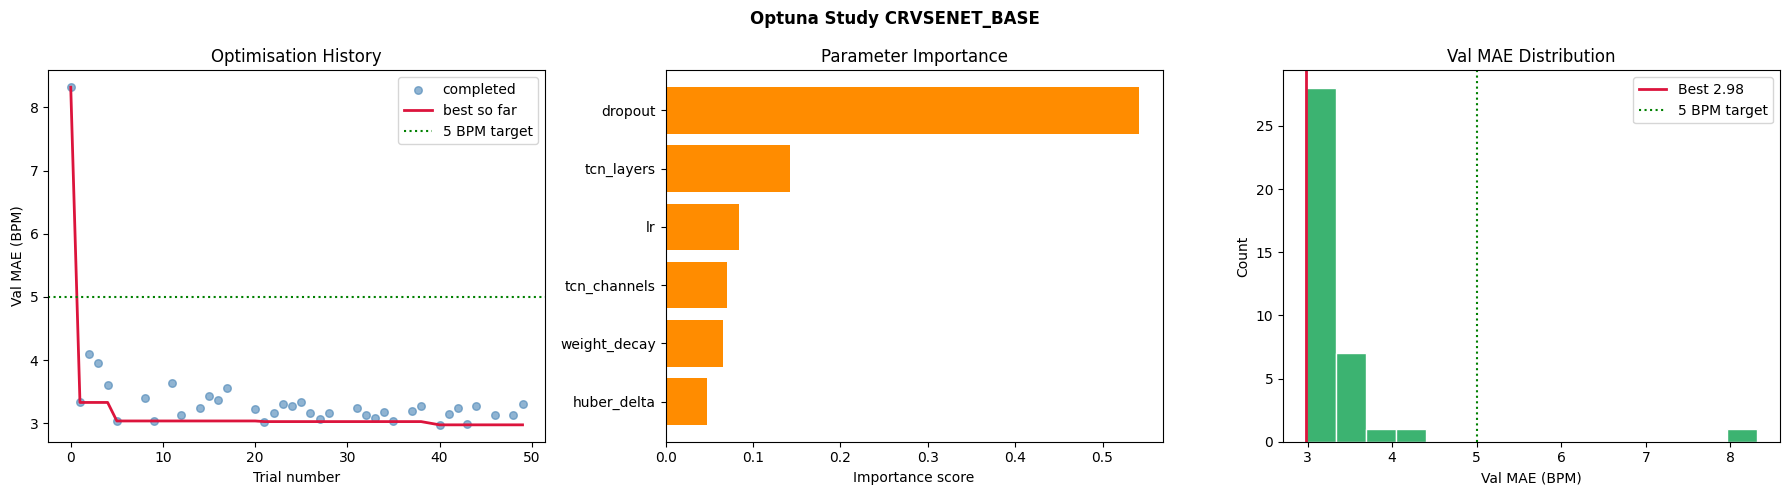

In [13]:
def plot_optuna_results(study: optuna.Study, model_name) -> None:

    trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    numbers = [t.number for t in trials]
    val_maes = [t.value  for t in trials]
    best_so_far = np.minimum.accumulate([t.value for t in sorted(trials, key=lambda t: t.number)])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Optuna Study {model_name}", fontweight="bold")

    # Trial val MAEs
    axes[0].scatter(numbers, val_maes, alpha=0.6, s=30, color="steelblue", label="completed")
    axes[0].plot(sorted(numbers), best_so_far,color="crimson", linewidth=2, label="best so far")
    axes[0].axhline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[0].set_xlabel("Trial number")
    axes[0].set_ylabel("Val MAE (BPM)")
    axes[0].set_title("Optimisation History")
    axes[0].legend()

    # Parameter importance — top 6
    try:
        importances = optuna.importance.get_param_importances(study)
        top_params  = list(importances.items())[:6]
        params, imps = zip(*top_params)
        axes[1].barh(params, imps, color="darkorange")
        axes[1].set_xlabel("Importance score")
        axes[1].set_title("Parameter Importance")
        axes[1].invert_yaxis()
    except Exception:
        axes[1].text(0.5, 0.5, "Importance\nnot available", ha="center", va="center", transform=axes[1].transAxes)

    # Val MAE distribution across completed trials
    axes[2].hist(val_maes, bins=15, color="mediumseagreen", edgecolor="white")
    axes[2].axvline(study.best_value, color="crimson", linewidth=2, label=f"Best {study.best_value:.2f}")
    axes[2].axvline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[2].set_xlabel("Val MAE (BPM)")
    axes[2].set_ylabel("Count")
    axes[2].set_title("Val MAE Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("optuna_study_results.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_optuna_results(study, MODEL_NAME)

## 13. Train model on best configuration (training on full train + val, evaluation on test set)

In [14]:
best_n_epochs = study.best_trial.last_step
print(f"Best trial converged at epoch : {best_n_epochs}")
print(f"Retraining on train+val for : {best_n_epochs} epochs")
print(f"(vs fixed N_EPOCHS={N_EPOCHS})")

print("Retraining best configuration...")
p = study.best_params

best_model = CRVSENet(
    in_channels = 1,
    base_channels = p["base_channels"],
    tcn_channels = p["tcn_channels"],
    tcn_layers = p["tcn_layers"],
    tcn_kernel = p["tcn_kernel"],
    dropout = p["dropout"],
    hr_min = HR_MIN,
    hr_max = HR_MAX,
).to(DEVICE)

# Train on train+val combined for final model
full_ds = CRVSEDataset(all_samples, train_keys | val_keys)
print(f"Full train set : {len(full_ds)} windows")
full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

loss_function = nn.HuberLoss(delta=p["huber_delta"])
optimizer = AdamW(best_model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=best_n_epochs, eta_min=p["lr"] / 100)

epoch_bar = tqdm(range(1, best_n_epochs + 1), desc="Final training", unit="epoch")
for epoch in epoch_bar:
    best_model.train()
    total_loss = 0.0
    for signals, labels in full_loader:
        signals, labels = signals.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        preds = best_model(signals)
        loss  = loss_function(preds, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    epoch_bar.set_postfix({"loss": f"{total_loss/len(full_loader):.3f}"})

# Test evaluation
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

best_model.eval()
all_preds = []
all_labels = []
all_subject_ids = []
all_dataset_ids  = []

with torch.inference_mode():
    for signals, labels in test_loader:
        preds = best_model(signals.to(DEVICE)).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

all_subject_ids = [test_ds.items[i]["subject_key"] for i in range(len(test_ds))]
all_dataset_ids = [test_ds.items[i]["dataset"] for i in range(len(test_ds))]
preds_np = np.array(all_preds, dtype=np.float32)
labels_np = np.array(all_labels, dtype=np.float32)

# Metrics
diff = preds_np - labels_np
mae = float(np.mean(np.abs(diff)))

full_evaluation(
    preds = preds_np,
    labels = labels_np,
    subject_ids = all_subject_ids,
    dataset_ids = all_dataset_ids,
    model_name  = "CRVSENet Tuned — POS only",
)

torch.save({
    "best_params" : study.best_params,
    "best_n_epochs" : best_n_epochs,
    "model_state" : best_model.state_dict(),
    "test_mae"    : mae,
}, f"{MODEL_NAME}_best.pt")
print("\nSaved -> crvse_tuned_best.pt")


Best trial converged at epoch : 50
Retraining on train+val for : 50 epochs
(vs fixed N_EPOCHS=50)
Retraining best configuration...
Dataset size: 8077 windows
Full train set : 8077 windows


Final training: 100%|██████████| 50/50 [02:22<00:00,  2.85s/epoch, loss=39.778]



FULL EVALUATION - CRVSENet Tuned — POS only

Window-level (n=1424 windows):
MAE : 3.06 BPM
RMSE : 4.62 BPM
MAPE : 3.91 %
Pearson r : 0.9473  (p=0.0000)
R² : 0.8887
BA bias : -1.27 BPM
BA LoA : [-9.98, 7.44] BPM

|error| <  5 BPM : 85.5% of windows
|error| < 10 BPM : 94.9% of windows
|error| < 15 BPM : 98.1% of windows

Subject-level metrics (n=29 subjects):
MAE : 2.37 BPM
RMSE : 2.85 BPM
r : 0.9872
BA bias: -1.11 BPM
BA LoA : [-6.25, 4.02] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
mcd_rppg         1174     2.51     3.68   0.9213
ubfc_phys         175     5.77     7.22   0.6884
ubfc_rppg          75     5.34     8.47   0.7859

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          284     2.37     3.80
normal low               833     2.69     4.23
normal high              178     4.77     6.42
tachycardia/exercise     